In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



In [2]:
df=pd.read_csv("Clean_Dataset.csv")

In [3]:
df

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955
...,...,...,...,...,...,...,...,...,...,...,...,...
300148,300148,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,69265
300149,300149,Vistara,UK-826,Chennai,Afternoon,one,Night,Hyderabad,Business,10.42,49,77105
300150,300150,Vistara,UK-832,Chennai,Early_Morning,one,Night,Hyderabad,Business,13.83,49,79099
300151,300151,Vistara,UK-828,Chennai,Early_Morning,one,Evening,Hyderabad,Business,10.00,49,81585


In [4]:
df.airline.value_counts()

airline
Vistara      127859
Air_India     80892
Indigo        43120
GO_FIRST      23173
AirAsia       16098
SpiceJet       9011
Name: count, dtype: int64

In [5]:
df.source_city.value_counts()

source_city
Delhi        61343
Mumbai       60896
Bangalore    52061
Kolkata      46347
Hyderabad    40806
Chennai      38700
Name: count, dtype: int64

In [6]:
df.destination_city.value_counts()

destination_city
Mumbai       59097
Delhi        57360
Bangalore    51068
Kolkata      49534
Hyderabad    42726
Chennai      40368
Name: count, dtype: int64

In [7]:
df.arrival_time.value_counts()

arrival_time
Night            91538
Evening          78323
Morning          62735
Afternoon        38139
Early_Morning    15417
Late_Night       14001
Name: count, dtype: int64

In [8]:
df.departure_time.value_counts()

departure_time
Morning          71146
Early_Morning    66790
Evening          65102
Night            48015
Afternoon        47794
Late_Night        1306
Name: count, dtype: int64

In [9]:
df.stops.value_counts()

stops
one            250863
zero            36004
two_or_more     13286
Name: count, dtype: int64

In [10]:
df['class'].value_counts()

class
Economy     206666
Business     93487
Name: count, dtype: int64

In [11]:
df['duration'].min()

0.83

In [12]:
df['duration'].max()

49.83

In [13]:
df['duration'].median()

11.25

In [14]:
#preprocessing

df=df.drop('Unnamed: 0',axis=1)
df=df.drop('flight',axis=1)

df['class']=df['class'].apply(lambda x: 1 if x=="Business" else 0)

In [15]:
df.stops=pd.factorize(df.stops)[0]

In [16]:
df=df.join(pd.get_dummies(df.airline,prefix='airline',dtype=int)).drop('airline',axis=1)
df=df.join(pd.get_dummies(df.source_city,prefix='source_city',dtype=int)).drop('source_city',axis=1)
df=df.join(pd.get_dummies(df.destination_city,prefix='destination_city',dtype=int)).drop('destination_city',axis=1)
df=df.join(pd.get_dummies(df.departure_time,prefix='departure_time',dtype=int)).drop('departure_time',axis=1)
df=df.join(pd.get_dummies(df.arrival_time,prefix='arrival_time',dtype=int)).drop('arrival_time',axis=1)



In [17]:
df

,stops,class,duration,days_left,price,airline_AirAsia,airline_Air_India,airline_GO_FIRST,airline_Indigo,airline_SpiceJet,...,departure_time_Evening,departure_time_Late_Night,departure_time_Morning,departure_time_Night,arrival_time_Afternoon,arrival_time_Early_Morning,arrival_time_Evening,arrival_time_Late_Night,arrival_time_Morning,arrival_time_Night
0,0,0,2.17,1,5953,0,0,0,0,1,...,1,0,0,0,0,0,0,0,0,1
1,0,0,2.33,1,5953,0,0,0,0,1,...,0,0,0,0,0,0,0,0,1,0
2,0,0,2.17,1,5956,1,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
3,0,0,2.25,1,5955,0,0,0,0,0,...,0,0,1,0,1,0,0,0,0,0
4,0,0,2.33,1,5955,0,0,0,0,0,...,0,0,1,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
300148,1,1,10.08,49,69265,0,0,0,0,0,...,0,0,1,0,0,0,1,0,0,0
300149,1,1,10.42,49,77105,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
300150,1,1,13.83,49,79099,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
300151,1,1,10.00,49,81585,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0


In [18]:
#traning regression model

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

X=df.drop('price',axis=1)
y=df.price

In [19]:
X_train,X_test,y_train,y_test=train_test_split(X,y, test_size=0.2,random_state=42)

In [28]:
reg=RandomForestRegressor(n_jobs=-1,n_estimators=50)
reg.fit(X_train,y_train)

RandomForestRegressor(n_estimators=50, n_jobs=-1)

In [32]:
reg.score(X_test,y_test)

0.9852459055780249

In [35]:
import math
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

y_pred=reg.predict(X_test)

print("R2:",r2_score(y_test,y_pred))
print("MAE:",mean_absolute_error(y_test,y_pred))
print("MSE:",mean_squared_error(y_test,y_pred))
print("RMSE:",math.sqrt(mean_squared_error(y_test,y_pred)))


R2: 0.9852459055780249
MAE: 1079.363634704609
MSE: 7588282.647162998
RMSE: 2754.683765364547


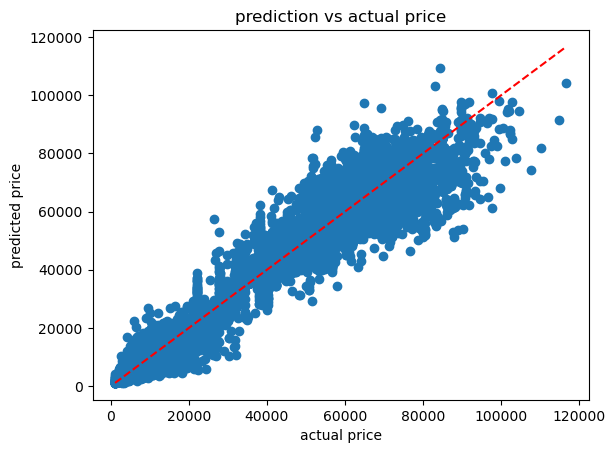

In [50]:
plt.scatter(y_test,y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("actual price")
plt.ylabel("predicted price")
plt.title("prediction vs actual price")
plt.show()

In [41]:
importances=dict(zip(reg.feature_names_in_,reg.feature_importances_))
sorted_importances=sorted(importances.items(),key=lambda x: x[1],reverse=True)

In [42]:
sorted_importances

[('class', 0.8799798967372376),
 ('duration', 0.05710400194655769),
 ('days_left', 0.018640875689237967),
 ('airline_Vistara', 0.005086933986128113),
 ('airline_Air_India', 0.004953243789787424),
 ('source_city_Delhi', 0.0038029765366557103),
 ('destination_city_Delhi', 0.0033774561361438363),
 ('source_city_Mumbai', 0.002222334875183849),
 ('destination_city_Kolkata', 0.0018984006317898441),
 ('stops', 0.0018704235070127122),
 ('destination_city_Mumbai', 0.0017995224266553552),
 ('source_city_Kolkata', 0.0017822200128636665),
 ('arrival_time_Evening', 0.0015899920921142521),
 ('destination_city_Hyderabad', 0.0014723408496831866),
 ('destination_city_Bangalore', 0.0013601545619278106),
 ('source_city_Hyderabad', 0.001306810996743582),
 ('source_city_Bangalore', 0.001145362519247603),
 ('departure_time_Evening', 0.0011407670332878692),
 ('arrival_time_Night', 0.0011028859345997768),
 ('arrival_time_Afternoon', 0.001050656641631405),
 ('source_city_Chennai', 0.0009281395830846852),
 ('de

Text(0.5, 1.0, 'feature importance')

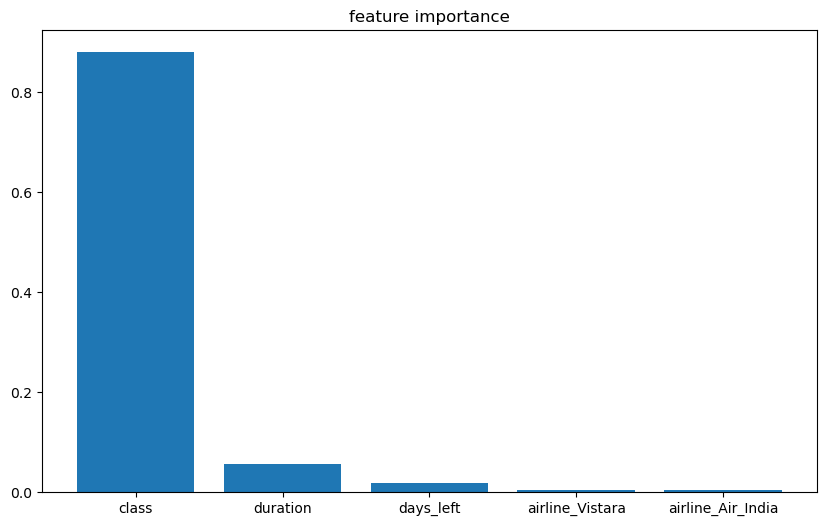

In [45]:
plt.figure(figsize=(10,6))
plt.bar([x[0] for x in sorted_importances[:5]],[x[1] for x in sorted_importances[:5]])
plt.title("feature importance")


In [47]:
# from sklearn.model_selection import GridSearchCV

# reg=RandomForestRegressor(n_jobs=-1)

# param_grid={
#     'n_estimators':[100,200,300],
#     'max_depth':[None,10,20,30],
#     'min_samples_split':[2,5,10],
#     'min_samples_leaf':[1,2,4],
#     'max_features':['auto','sqrt']
# }

# grid_search=GridSearchCV(reg,param_grid,cv=5)
# grid_search.fit(X_train.y_train)
# best_params=grid_search.best_params_

In [48]:
def predict_flight_price(reg):
    sample = pd.DataFrame(0, index=[0], columns=X_train.columns)

    sample['duration'] = 2.5
    sample['days_left'] = 15
    sample['class'] = 0

    sample['airline_Indigo'] = 1
    sample['source_city_Delhi'] = 1
    sample['destination_city_Mumbai'] = 1
    sample['departure_time_Morning'] = 1
    sample['arrival_time_Afternoon'] = 1

    return reg.predict(sample)[0]

print("Predicted Price:", predict_flight_price(reg))

Predicted Price: 3675.8


In [49]:
import joblib

# Save dataframe
joblib.dump(df, "flight_data.joblib")

['flight_data.joblib']